## Naive Baise

Accuracy: 0.7337662337662337
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.77      0.80       109
           1       0.54      0.64      0.59        45

    accuracy                           0.73       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.75      0.73      0.74       154



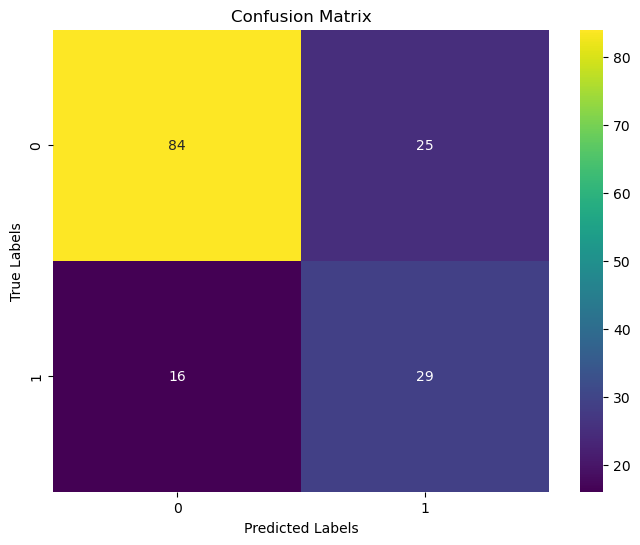

In [3]:
# import library
import pandas as pa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB  # Import Gaussian Naive Bayes
from imblearn.over_sampling import SMOTE
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# dataset
dataset = pa.read_csv('diabetes.csv')

# Features
x = dataset.drop(['Outcome'], axis=1)

# Target
y = dataset['Outcome']

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

# scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Data augmentation using SMOTE
smote = SMOTE(random_state=42)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

# Create Gaussian Naive Bayes classifier
classifier_nb = GaussianNB()

# Train the model
classifier_nb.fit(x_train_resampled, y_train_resampled)

# Predict target of test data based on test data target
y_pred = classifier_nb.predict(x_test_scaled)

# Finding accuracy by comparing actual response values (y_test) with predicted response value (y_pred)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

# Classification report for additional metrics
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()









### Decision tree